In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "./dataset/PlantVillage",
    shuffle=True,
    image_size=(256, 256),
    batch_size=32
)

Found 2152 files belonging to 3 classes.


In [4]:
class_name=dataset.class_names
print(class_name)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


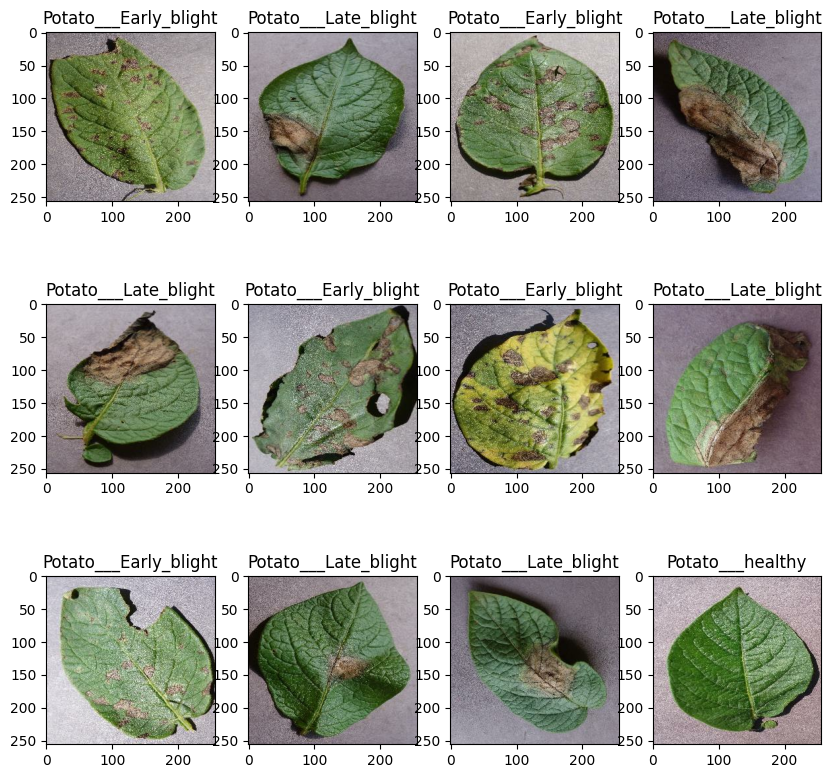

In [5]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):

        ax=plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_name[label_batch[i]])

80% ===> traning
20% ===> 10% testing + 10% validation

In [6]:
train_size=0.8
len(dataset)*0.8

54.400000000000006

In [7]:
train_ds=dataset.take(56)

In [8]:
val_size=0.1
len(dataset)*0.1

6.800000000000001

In [9]:
val_ds=dataset.skip(56).take(7)

In [10]:
test__size=0.1
len(dataset)*0.1

6.800000000000001

In [11]:
test_ds=dataset.skip(63)

In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
len(train_ds), len(val_ds), len(test_ds)

(54, 6, 8)

In [15]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [16]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(256, 256),
    layers.experimental.preprocessing.Rescaling(1./255),
])

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

In [18]:
input_shape=(32,256,256,3)

In [19]:
model=models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,3,activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,3,activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(3,activation='softmax')
])

In [20]:
model.build(input_shape=input_shape)

In [21]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [ ]:
model.compile(
    optimizer="adam ",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [23]:
history=model.fit(train_ds,epochs=50,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 1/50


54/54 [==============================] - 240s 4s/step - loss: 0.7046 - accuracy: 0.7552 - val_loss: 0.3143 - val_accuracy: 0.8906
Epoch 2/50
54/54 [==============================] - 202s 4s/step - loss: 0.3092 - accuracy: 0.8785 - val_loss: 0.2201 - val_accuracy: 0.9271
Epoch 3/50
54/54 [==============================] - 149s 3s/step - loss: 0.2556 - accuracy: 0.9005 - val_loss: 0.1212 - val_accuracy: 0.9635
Epoch 4/50
54/54 [==============================] - 147s 3s/step - loss: 0.1808 - accuracy: 0.9300 - val_loss: 0.7572 - val_accuracy: 0.7240
Epoch 5/50
54/54 [==============================] - 154s 3s/step - loss: 0.1246 - accuracy: 0.9572 - val_loss: 0.6344 - val_accuracy: 0.7604
Epoch 6/50
54/54 [==============================] - 133s 2s/step - loss: 0.1444 - accuracy: 0.9427 - val_loss: 0.2256 - val_accuracy: 0.8906
Epoch 7/50
54/54 [==============================] - 135s 2s/step - loss: 0.1277 - accuracy: 0.9508 - val_loss: 0.2824 - val_accuracy: 0.8802
Epoch 8/50
54/54 [======

In [24]:
model.evaluate(test_ds)

8/8 [==============================] - 9s 686ms/step - loss: 0.1565 - accuracy: 0.9414


[0.1565212458372116, 0.94140625]

In [27]:
import os

model_version=1

model.save(f"{model_version}")

INFO:tensorflow:Assets written to: 1\assets


INFO:tensorflow:Assets written to: 1\assets
